![](https://www.dii.uchile.cl/wp-content/uploads/2021/06/Magi%CC%81ster-en-Ciencia-de-Datos.png)

**MDS7202: Laboratorio de Programación Científica para Ciencia de Datos**

### 👨‍🏫👩‍🏫 Cuerpo Docente:

- Profesor: Pablo Badilla, Diego Cortez
- Auxiliar: Melanie Peña Torres, Valentina Rojas Osorio
- Ayudante: Javiera Arévalo, Tamara Carrasco, Ignacio Reyes

### 👨‍💻👩‍💻 Estudiantes:
- Estudiante n°1: Leonardo Navarro
- Estudiante n°2: Matias Sweet

_Por favor, lean detalladamente las instrucciones de la tarea antes de empezar a escribir._

---

## Reglas

El proyecto consta de 3 partes: **Informe de Análisis** (30%), **Construcción del Modelo** (40%) y **Despliegue del Modelo** (30%). Este notebook corresponde a la **Parte 2 - Construcción del Modelo**, y asume que ya completaste la **Parte 1 - Informe de Análisis**.

### **Requisitos del proyecto**
- **Grupos**: Formar equipos de **2 personas**.
- **Plazo de entrega**: Hasta el Viernes 10 de Julio
- **Consultas**: Cualquier duda fuera del horario de clases debe ser planteada en el foro correspondiente. Los mensajes enviados al equipo docente serán respondidos únicamente por este medio. Por favor, revisen las respuestas anteriores en el foro antes de realizar nuevas consultas.
- **Plagio**: La copia o reutilización no autorizada de trabajos de otros grupos está **estrictamente prohibida**. El incumplimiento de esta norma implicará la anulación inmediata del proyecto y una posible sanción académica.
- **Material permitido**: Pueden usar cualquier material del curso, ya sea notas, lecturas, códigos, o referencias proporcionadas por los docentes, que consideren útil para el desarrollo del proyecto.

---

## 📊 Distribución de Puntaje

La nota va de **1.0 a 7.0** (escala chilena): **1.0 de base + 6.0 puntos** repartidos como se muestra. Solo se evalúa **lo que implementas y respondes**; el **código y los recursos entregados no tienen puntaje**.

| Sección | Qué se evalúa | Puntaje |
|---|---|---:|
| **1 — Preparación** | 5 preguntas conceptuales (0.1 c/u) | 0.5 |
| **2 — Introducción a la Experimentación** | 3 preguntas (0.2 c/u) | 0.6 |
| **3 — Barrido de Combinaciones** | 10 experimentos (0.2 c/u) = 2.0 · preguntas LogReg 0.9 · Árbol/RF 0.2 · LightGBM 0.4 · MLP 0.4 | 3.9 |
| **4 — Selección del Mejor Modelo** | 5 preguntas (0.2 c/u) | 1.0 |
| | **Total puntos** | **6.0** |
| | **+ Base** | **1.0** |
| | **Nota máxima** | **7.0** |

> El puntaje de cada pregunta y experimento aparece **inline** como `(0.X pts)`.

Esta nota corresponde a la nota de la **Parte 2** que equivale a un **40%** de la nota del proyecto final. Para obtener la nota final, las notas individuales de cada parte se ponderan de la siguiente manera.

| Parte              | Ponderación |
|--------------------|------------:|
| 1 — Análisis       | 30%         |
| **2 — Modelo**     | **40%**     |
| 3 — Despliegue     | 30%         |


## 📖 Introducción

<p align="center">
    <img src="./chaucherapp.jpg" alt="Alt Text" width="700">
</p>

La app chilena **ChaucherApp** ha emergido recientemente como una de las nuevas apps *FinTech* que apuesta por dominar en un competitivo mercado. Esta app ofrece una billetera digital que permite hacer transferencias, tarjetas digitales que permiten comprar, y servicios financieros como préstamos, seguros e inversiones.

Sin duda es sorprendente que **ChaucherApp** sea uno de los líderes de la industria fintech, siendo una empresa tan joven. En las palabras del CEO de la empresa, el Sr. Querty _'El gran éxito de ChaucherApp se debe a que entendimos la importancia de escuchar y responder eficientemente al cliente'_. En efecto, **ChaucherApp** fue diseñada desde el comienzo con una robusta arquitectura digital relacionada al **Soporte al cliente**.

Durante años, **ChaucherApp** ha logrado dar respuesta satisfactoria a cientos de tickets de soporte al cliente al mes, lo que le ha permitido inspirar confianza y prestigio. Por supuesto, esto también ha generado una gran cantidad de datos que pueden ser útiles para las siguientes etapas de crecimiento de la empresa. Y es que, a medida que el mercado se hace más competitivo, se hace más necesario aumentar la eficiencia de los procesos de respuesta de tickets, por lo que el Sr. Querty ha optado por **automatizar el proceso** incorporando inteligencia artificial.

Luego de intensa planificación ejecutiva y jornadas de analítica, han decidido que el primer paso para automatizar será el de desarrollar un modelo de **priorización de tickets** de soporte al cliente utilizando **modelos de lenguaje** y **aprendizaje de máquinas**. De esta manera podrán optimizar recursos humanos mientras se desarrollan otras herramientas.

Para lograr esta tarea, te han encargado analizar datos históricos de tickets de soporte al cliente que ya han sido manualmente priorizados, presentes en el archivo `data/tickets.parquet`. En él, encontrarás tickets con el contenido del ticket, categoría, canal, fecha y priorización, que puede ser `Baja`, `Media`, `Alta` o `Crítica`. Tu objetivo es utilizar esa data y los medios, algoritmos y estrategias que estimes convenientes para construir un **modelo clasificador** que sea capaz de predecir esta categoría en base al texto y atributos del ticket.

Con esta información, tus tareas a realizar son primero **analizar y entender los datos**, luego **construir un modelo de inferencia**, y finalmente **implementar ese modelo** para que el equipo de ejecutivos de ChaucherApp pueda utilizarlo.

---

# Parte 2 - Construcción del Modelo

En la Parte 1 entendiste el problema y exploraste los datos. Recapitulemos lo que ya sabemos y que guiará todo este notebook:

- El problema es de **clasificación multiclase**: predecir `Nivel_Prioridad` ∈ {`Baja`, `Media`, `Alta`, `Critica`}.
- Las clases están **desbalanceadas** (Media ~39%, Baja ~36%, Alta ~17%, Critica ~7%).
- La variable `Tiempo_de_Resolución_Horas` es **data leakage** (no está disponible en inferencia), así que **no la usaremos**.
- Contamos con features de **texto** (`Asunto_Ticket`, `Contenido_Ticket`), **categóricas** (`Canal_Ticket`, `Categoría_Problema`), una **numérica** (`N_Caracteres_Ticket`) y los **embeddings** (`gemini-embedding-001`, 1024 dimensiones).
- Siguiendo la decisión de la Parte 1, la **métrica a optimizar será el _macro recall_** (promedio simple del recall por clase), para no descuidar a la clase `Critica`.

La idea de esta parte es experimentar con muchas combinaciones de **(features × modelo)**, optimizando los hiperparámetros con **Optuna** y registrando todo en **MLflow**, para finalmente elegir y exportar el mejor.

> **MLflow**: usaremos MLflow para *experiment tracking*. Como MLflow 3.x deprecó el backend de archivos, usaremos un backend de base de datos local (`sqlite:///mlflow.db`). Si no lo tienes instalado:
> ```bash
> uv pip install "mlflow>=3.14" ipywidgets optuna scikit-learn "pandas<3" optuna_integration lightgbm nltk
> ```
> Para abrir la interfaz gráfica y comparar tus runs:
> ```bash
> mlflow ui --backend-store-uri sqlite:///mlflow.db
> ```

---

# Sección 1 - Preparación — (0.5 pts)

Antes de modelar, dejaremos listo el **protocolo experimental**: definir el split y la métrica y el ejecutor de experimentos antes de ejecutar cualquier experimento.

> Este código será dado, por ende, no tendrá puntaje.

Tareas de esta sección:

1. Importar librerías, configurar MLflow (tracking URI + experimento)., fijar semillas y definir las **constantes compartidas**.
2. Cargar `tickets.parquet` y `embeddings.parquet`. Descartar el *data leakage*, contruir una única columna de texto y armar un **único** dataframe `X_full` que contenga las features tabulares, el texto y las 1024 columnas de embedding.
3. Separar en **train / val / test (60/20/20) estratificado**.

In [ ]:
# 1. Importar librerías, fijar semillas y configurar constantes

import re

import joblib
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import optuna
import pandas as pd
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split

optuna.logging.set_verbosity(optuna.logging.WARNING)
mlflow.set_tracking_uri("sqlite:///mlflow.db")
EXPERIMENT_NAME = "ProyectoMDS7202"

if mlflow.get_experiment_by_name(EXPERIMENT_NAME) is None:
    mlflow.create_experiment(EXPERIMENT_NAME)

mlflow.set_experiment(EXPERIMENT_NAME)

# Definir constantes y fijar semillas
SEED = 42

np.random.seed(SEED)

ORDEN_CLASES = ["Baja", "Media", "Alta", "Critica"]
NUM_COLS = ["N_Caracteres_Ticket"]
CAT_COLS = ["Canal_Ticket", "Categoría_Problema"]
TEXT_COL = "Texto"

# 2. Cargar y preprocesar los datos

# Cargar datos tabulares
df = pd.read_parquet("data/tickets.parquet")

# Descartamos la variable con data leakage detectada en la Parte 1
df = df.drop(columns=["Tiempo_de_Resolución_Horas"])

# Combinar campos de texto en una sola columna "Texto"
df["Texto"] = df["Asunto_Ticket"].fillna("") + " " + df["Contenido_Ticket"].fillna("")

# Cargar Embeddings (mismo orden de filas que df).
embeddings = pd.read_parquet("data/embeddings.parquet")
EMBEDDING_COLS = list(embeddings.columns)

# Generar único dataframe con todas las variables: tabular + texto + embeddings.
X_full = pd.merge(
    df.drop(columns=["Nivel_Prioridad", "Asunto_Ticket", "Contenido_Ticket"]),
    embeddings,
    on="Id_Ticket",
).drop(columns=["Id_Ticket"])
y = df["Nivel_Prioridad"]

print("---------- EDA Breve ----------\n")
print("X_full:", X_full.shape, "| columnas de embedding:", len(EMBEDDING_COLS))
print("Clases:", sorted(y.unique()))
display(X_full.head(10))
display(y.head(10))
display((y.value_counts() / len(y)).mul(100).round(2).rename("Distribución Labels (%)", inplace=True))

El experimento ya existe
---------- EDA Breve ----------

X_full: (2000, 1031) | columnas de embedding: 1024
Clases: ['Alta', 'Baja', 'Critica', 'Media']


,N_Caracteres_Ticket,Canal_Ticket,Categoría_Problema,Usuario-Tipo_de_Cuenta,Usuario-Antiguedad_Cuenta_Dias,Fecha_Envío,Texto,embedding_dim_1,embedding_dim_2,embedding_dim_3,...,embedding_dim_1015,embedding_dim_1016,embedding_dim_1017,embedding_dim_1018,embedding_dim_1019,embedding_dim_1020,embedding_dim_1021,embedding_dim_1022,embedding_dim_1023,embedding_dim_1024
0,531,Whatsapp,Cuenta,Premium,159,2024-01-02,Error al iniciar sesión en nuevo celular por d...,-0.011585,-0.008728,0.012878,...,-0.011539,-0.016249,0.004422,-0.022274,0.004511,0.001428,-0.007812,-0.020485,-0.001888,-0.000408
1,784,Whatsapp,Otro,Premium,192,2024-01-02,Error al actualizar correo electrónico: bloque...,0.014494,0.004070,0.011298,...,-0.019967,-0.008424,-0.002084,-0.002761,-0.004148,-0.007131,-0.012717,-0.019045,-0.015172,0.004308
2,600,Whatsapp,Fraude,Free,314,2024-01-02,Cobro desconocido en mi tarjeta digital Hola b...,-0.010936,0.020796,0.011680,...,-0.021763,-0.007094,-0.011453,-0.001084,-0.005820,-0.015085,0.003200,-0.019789,-0.018502,-0.001085
3,659,Whatsapp,Cuenta,Free,228,2024-01-02,"Cuenta bloqueada sin aviso, necesito ayuda urg...",0.003248,0.005420,0.003422,...,-0.019830,-0.007490,-0.013525,0.000086,-0.011983,0.007148,-0.002536,-0.016200,-0.003927,-0.004028
4,853,Whatsapp,Otro,Free,72,2024-01-03,Me descontaron plata del cajero y no salió el ...,-0.010437,0.013634,0.009859,...,-0.006401,-0.001971,0.002344,-0.010598,-0.011034,-0.012039,-0.000857,-0.009420,-0.006597,0.012463
5,672,Whatsapp,Otro,Free,71,2024-01-03,Problemas con retiro en cajero y saldo retenid...,-0.006699,0.015320,0.004916,...,-0.002004,-0.009383,0.002027,-0.004618,-0.005886,0.001436,-0.002760,-0.010959,-0.019190,0.013137
6,691,Correo,Cuenta,Free,27,2024-01-03,Problema con transferencia no recibida: dinero...,-0.001424,0.013316,-0.001574,...,-0.017849,0.000331,-0.004115,-0.007396,-0.016886,-0.004226,0.000309,-0.011096,-0.009890,0.001992
7,782,Whatsapp,Técnica,Free,193,2024-01-05,Error al acceder a la sección de inversiones (...,-0.001278,0.014927,0.002564,...,-0.021633,-0.006482,0.000185,-0.000037,-0.001324,-0.010792,0.003312,-0.020291,-0.002917,-0.004307
8,652,Página Web,Técnica,Free,283,2024-01-05,"Error en transferencia y saldo descontado, ayu...",0.003861,-0.008191,0.009408,...,-0.009119,-0.002006,0.003867,-0.010697,-0.020366,-0.003357,0.003855,-0.027547,-0.014218,0.010238
9,427,Whatsapp,Pregunta general,Free,72,2024-01-05,duda con inversiones y error en la app hola bu...,-0.010484,0.003417,0.022390,...,-0.016919,-0.004394,-0.004335,-0.009940,0.002788,-0.003919,0.001589,-0.023548,-0.008324,-0.010632


0     Baja
1    Media
2     Baja
3    Media
4    Media
5    Media
6    Media
7    Media
8    Media
9     Baja
Name: Nivel_Prioridad, dtype: object

Nivel_Prioridad
Media      39.45
Baja       36.15
Alta       17.50
Critica     6.90
Name: Distribución Labels (%), dtype: float64

In [2]:
# 3. Split train/val/test

print("Splits \n")

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X_full,
    y,
    test_size=0.4,
    stratify=y,
    random_state=SEED,
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp,
    y_tmp,
    test_size=0.5,
    stratify=y_tmp,
    random_state=SEED,
)

print("Elementos por set | Train:", len(X_train), "| Val:", len(X_val), "| Test:", len(X_test))
d_y_train = (
    (y_train.value_counts() / len(y_train)).mul(100).round(2).rename("Distribución Labels Train (%)", inplace=True)
)
d_y_val = (y_val.value_counts() / len(y_val)).mul(100).round(2).rename("Distribución Labels Val (%)", inplace=True)
d_y_test = (y_test.value_counts() / len(y_test)).mul(100).round(2).rename("Distribución Labels Test (%)", inplace=True)
display(pd.concat([d_y_train, d_y_val, d_y_test], axis=1))

Splits 

Elementos por set | Train: 1200 | Val: 400 | Test: 400


,Distribución Labels Train (%),Distribución Labels Val (%),Distribución Labels Test (%)
Nivel_Prioridad,,,
Media,39.42,39.5,39.50
Baja,36.17,36.0,36.25
Alta,17.50,17.5,17.50
Critica,6.92,7.0,6.75


Antes de modelar, responde:

1. ¿Por qué fijamos el split (train/val/test) **antes** de entrenar cualquier modelo? ¿Qué riesgo evitamos? **(0.1 pts)**
2. En general, siempre vamos a utilizar el enfoque de optimización de hiperparámetros. ¿Por qué utilizar train/val/test y no solo train/test es importante? ¿Qué otra técnica hay para evitar esto? **(0.1 pts)**
3. ¿Por qué usamos un split **estratificado**? ¿qué problema causaría un split aleatorio en val/test asumiendo que para esta cantidad de datos, la métricas pueden ser ruidosas? Apoya tu respuesta ejecutando el bloque `Split train/val/test` de la celda anterior comentando el parámetro `stratify` y justifica usando los resultados obtenidos. Luego, recuerda volver a agregar el parámetro, de lo contrario, tus resultados se podrían ver afectados. **(0.1 pts)**
4. ¿Por qué la métrica adecuada aquí es el **macro recall** y no, por ejemplo, el _accuracy_? Conéctalo con el desbalance y con lo que respondiste en la Parte 1. **(0.1 pts)**
5. ¿Qué es el **experiment tracking** y qué ganamos al registrar cada modelo en MLflow en lugar de solo imprimir métricas? Piensa en qué pasa si reinicias, por ejemplo, el notebook de Jupyter. **(0.1 pts)**

_Subtotal preguntas: 0.5 pts_

**Responde aquí**

1. Fijamos el split antes de tocar cualquier modelo para que la evaluación sea honesta: el conjunto de test queda apartado y no influye en ninguna decisión de modelado (ni preprocesamiento, ni elección de features, ni hiperparámetros). El riesgo que evitamos es el data leakage entre conjuntos, es decir que información del test se filtre al entrenamiento, por ejemplo si ajustáramos un scaler o el vocabulario de BoW usando todos los datos. Si eso pasa, las métricas de test quedan infladas y dejan de ser una estimación creíble de cómo se comportará el modelo con datos nuevos.

2. Porque vamos a optimizar hiperparámetros, y eso implica tomar decisiones mirando una métrica. Si solo tuviéramos train/test y eligiéramos los hiperparámetros mirando el test, estaríamos usando el test para ajustar el modelo y dejaría de ser un conjunto "no visto": la métrica final quedaría sesgada y optimista. Con tres conjuntos optimizamos en validation y reservamos el test puro para una única medición final. La técnica alternativa es la validación cruzada (k-fold, idealmente estratificada): en vez de un único val, se rota la partición de validación dentro del train, lo que da una estimación más estable a costa de más cómputo, y el test se sigue reservando aparte.

3. Usamos un split estratificado para que train, val y test conserven la misma proporción de clases que el dataset completo, lo cual es crítico con una clase tan chica como Critica (6.9%). Al comentar `stratify` y rehacer el split (volviéndolo aleatorio), las proporciones se desvían: el test pasa de 6.75% a 5.75% de Critica (de 27 a 23 casos) y, por ejemplo, Baja baja de 36.25% a 33.25% mientras Alta sube a 19.5%. Con tan pocos ejemplos de Critica, esas diferencias hacen que el recall de esa clase se calcule sobre una muestra distinta y más ruidosa en cada partición, así que el macro recall se vuelve inestable y la comparación entre modelos deja de ser confiable: estaríamos comparando modelos sobre conjuntos que ni siquiera representan bien el problema. El split estratificado, en cambio, mantiene val y test alineados con el ~6.9% real de Critica (7.0% y 6.75%).

4. Porque las clases están desbalanceadas (Media 39%, Baja 36%, Alta 17%, Critica 7%) y lo que más importa al negocio es detectar los tickets urgentes. El accuracy premia acertar la clase mayoritaria: un modelo que ignore por completo a Critica igual tendría un accuracy alto, lo que esconde justo el fracaso que no podemos permitir. El recall mide, por clase, qué proporción de los casos reales se detecta, y la agregación macro promedia las cuatro clases con el mismo peso, sin que Media y Baja tapen a Critica. Es exactamente lo que concluimos en la Parte 1: la métrica adecuada es el macro recall, porque obliga al modelo a no descuidar a las clases minoritarias y urgentes.

5. El experiment tracking es registrar de forma sistemática cada ejecución de modelado: sus hiperparámetros, métricas, artefactos (gráficos, modelos) y metadatos, de modo que cada run quede guardado e identificable. Frente a solo imprimir métricas en el notebook, MLflow nos da persistencia y comparabilidad: si reiniciamos el kernel o cerramos Jupyter, los prints se pierden, pero los runs siguen en `mlflow.db` y se pueden volver a consultar, ordenar y comparar entre sí (por ejemplo, rankear todas las combinaciones por macro recall en val). Además guarda el modelo entrenado y los artefactos de cada run, lo que hace el proceso reproducible y permite recuperar y desplegar después el mejor modelo sin tener que reentrenar.


---

# Sección 2 - Introducción a la Experimentación — (0.6 pts)

La idea de la experimentación de este lab es que puedan probar muchas combinaciones de modelos y subconjuntos de features para resolver el problema.
Para no repetir el código de `Optuna` + `MLflow` una y otra vez, encapsularemos todo en **dos clases (ejecutor de experimentos y experimento abstracto) las cuales se te serán provistas**.

La idea de esta abstracción es finalmente que ustedes no definan el cómo ejecutan el experimento (código muy estándar), si no que simplemente definan la pipeline y el espacio de hiperparámetros a probar. 

- **`AbstractExperiment`**: define el *contrato* de un experimento. Cada experimento que ustedes hagan debe ser una **subclase** que implemente estos 4 métodos:
  - `model_name` (propiedad): Nombre del modelo a probar. Sirve para identificar el run.
  - `feature_set` (propiedad): Subconjunto de features a utilizar. Sirve para identificar el run.
  - `build_pipeline(hparams) -> Pipeline`: construye tu `ColumnTransformer` + modelo, parametrizado por `hparams`.
  - `generate_trial_hparams(trial) -> dict`: define el espacio de búsqueda de Optuna.
  
Mas adelante habrá un ejemplo de cómo implementar esto.

- **`ExperimentExecutor`**: recibe un experimento y se encarga del resto: corre **Optuna** (optimizando macro recall en **val**, cada *trial* como run anidado en MLflow), reentrena la mejor configuración con **train+val** y la evalúa en **test**, registrando todo en MLflow.

Esto nos garantiza que todos los modelos se comparen con el mismo protocolo.

In [3]:
import abc

import mlflow
import mlflow.sklearn
import numpy as np
import optuna
import pandas as pd
from optuna.integration.mlflow import MLflowCallback
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    recall_score,
)
from sklearn.pipeline import Pipeline


class AbstractExperiment(abc.ABC):
    """Experimento Abstracto.

    Permite que más adelante definan los experimentos a ejecutar.
    """

    @property
    @abc.abstractmethod
    def model_name(self) -> str:
        """Nombre del modelo, p.ej. 'Regresión_Logística', 'Arbol_de_Decision', 'LightGBM'..."""
        raise NotImplementedError()

    @property
    @abc.abstractmethod
    def feature_set(self) -> str:
        """Identificador del conjunto de features: 'Base', 'BoW', 'Embeddings', 'Todo', ..."""
        raise NotImplementedError()

    @property
    def study_name(self) -> str:
        """Identidad única de la combinación modelo × features. - Esta no debe ser redefinida"""
        return f"{self.model_name}__{self.feature_set}"

    @abc.abstractmethod
    def build_pipeline(self, hparams: dict) -> Pipeline:
        """Construye la pipeline a partir de los hiperparámetros entregados por Optuna.

        En este método deberán generar tanto el ColumnTransformer, como también el Pipeline,
        basándose en los parámetros entregados en hparams y dejando fijo el resto.
        Luego, deben retornar el Pipeline generado.
        """
        raise NotImplementedError()

    @abc.abstractmethod
    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        """Genera los hiperparámetros a partir del trial de optuna que permitirán construir el pipeline.

        En este método deberán retornar un diccionario con los hiperparámetros generados por Optuna
        que luego, permitirán construir el Pipeline.

        Ejemplo:
        ```python
        return {"C": trial.suggest_float("C", 1e-3, 1e2, log=True)}
        ```
        """

        raise NotImplementedError()


class ExperimentExecutor:
    """Ejecutor de experimentos.

    Esta clase permite ejecutar un experimento de forma estandarizada y luego logear sus resultados a MLFlow.

    NO MODIFICAR.
    """

    def refit_and_eval_with_test(
        self,
        experiment: AbstractExperiment,
        best_params: dict,
        X_train: pd.DataFrame,
        y_train: pd.DataFrame,
        X_val: pd.DataFrame,
        y_val: pd.DataFrame,
        X_test: pd.DataFrame,
        y_test: pd.DataFrame,
        run_name: str,
        parent_run_id: str | None = None,
    ) -> float:
        """Reentrena con train+val la mejor config, evalúa en test (macro recall).

        Registra params/métricas/matriz de confusión/classification report en MLflow
        y devuelve el macro recall de test.
        """

        X_train_final = pd.concat([X_train, X_val], axis=0)
        y_train_final = pd.concat([y_train, y_val], axis=0)
        trained_pipeline = experiment.build_pipeline(best_params).fit(X_train_final, y_train_final)

        # evalúa sobre el conjunto con el que realmente se entrenó
        y_train_pred = trained_pipeline.predict(X_train_final)
        y_test_pred = trained_pipeline.predict(X_test)

        mr_final_train = float(recall_score(y_train_final, y_train_pred, average="macro"))
        mr_test = float(recall_score(y_test, y_test_pred, average="macro"))

        with mlflow.start_run(run_name=run_name):
            mlflow.set_tag("stage", "refit_final")
            mlflow.set_tag("study_name", experiment.study_name)
            # tags estructurados para agrupar/filtrar en la UI
            mlflow.set_tag("model_name", experiment.model_name)
            mlflow.set_tag("feature_set", experiment.feature_set)
            if parent_run_id is not None:
                mlflow.set_tag("parent_run_id", parent_run_id)

            if best_params:
                mlflow.log_params(best_params)

            # tamaños de los splits para reproducibilidad
            mlflow.log_params(
                {
                    "n_train": len(X_train),
                    "n_val": len(X_val),
                    "n_train_final": len(X_train_final),
                    "n_test": len(X_test),
                }
            )

            mlflow.log_metric("macro_recall_final_train", mr_final_train)
            mlflow.log_metric("macro_recall_test", mr_test)

            # métricas por clase consultables desde el reporte como dict
            report_dict = classification_report(y_test, y_test_pred, output_dict=True)
            for label, metrics in report_dict.items():
                if isinstance(metrics, dict):
                    safe_label = str(label).replace(" ", "_")
                    mlflow.log_metric(f"recall_test_{safe_label}", metrics["recall"])
                    mlflow.log_metric(f"precision_test_{safe_label}", metrics["precision"])
                    mlflow.log_metric(f"f1_test_{safe_label}", metrics["f1-score"])

            fig, ax = plt.subplots(figsize=(4.5, 4))
            ConfusionMatrixDisplay.from_predictions(
                y_test,
                y_test_pred,
                labels=ORDEN_CLASES,
                xticks_rotation=45,
                colorbar=False,
                ax=ax,
            )
            ax.set_title(f"{run_name} (test)")
            fig.tight_layout()
            mlflow.log_figure(fig, "matriz_confusion_test.png")
            plt.close(fig)

            # --- Permutation importance sobre el modelo refit (evaluada en test) ---
            # Permutamos cada columna de ENTRADA que el modelo realmente usa y medimos la caída
            # del macro recall. Con embeddings son cientos de columnas sin significado individual:
            # la idea es justamente evidenciar que no son interpretables una a una.
            ct_refit = trained_pipeline.steps[0][1]  # ColumnTransformer (1er paso del pipeline)
            used_cols = []
            for _, trans, cols in ct_refit.transformers_:
                if trans == "drop":
                    continue
                used_cols += [cols] if isinstance(cols, str) else list(cols)

            pi = permutation_importance(
                trained_pipeline,
                X_test[used_cols],
                y_test,
                scoring="recall_macro",
                n_repeats=5,
                random_state=SEED,
            )
            top = np.argsort(pi.importances_mean)[-20:]  # top-20 por importancia media
            fig_pi, ax_pi = plt.subplots(figsize=(6, max(3, 0.32 * len(top))))
            ax_pi.barh(
                [used_cols[i] for i in top],
                pi.importances_mean[top],
                xerr=pi.importances_std[top],
                color="#4C72B0",
            )
            ax_pi.set_xlabel("Caída de macro recall al permutar (importancia)")
            ax_pi.set_title(f"Permutation importance — {run_name} (top 20, test)")
            fig_pi.tight_layout()
            mlflow.log_figure(fig_pi, "permutation_importance_test.png")
            plt.close(fig_pi)

            clf_report = classification_report(y_test, y_test_pred, output_dict=False)
            mlflow.log_text(str(clf_report), "classification_report_test.txt")

            signature = mlflow.models.infer_signature(X_train_final, y_test_pred)
            # cloudpickle: el serializador estricto (skops) rechaza el tokenizador propio y joblib.Memory
            mlflow.sklearn.log_model(
                trained_pipeline,
                name="model",
                signature=signature,
                input_example=X_train_final.head(3),
                serialization_format="cloudpickle",
            )

        print(f"{run_name:32s} | Macro recall final_train={mr_final_train:.3f}  test={mr_test:.3f}")
        return mr_test

    def run_experiment(
        self,
        experiment: AbstractExperiment,
        X_train: pd.DataFrame,
        y_train: pd.DataFrame,
        X_val: pd.DataFrame,
        y_val: pd.DataFrame,
        X_test: pd.DataFrame,
        y_test: pd.DataFrame,
        timeout_seconds: int | None,
        n_trials: int | None,
    ):
        """Optimiza con Optuna (cada trial = run anidado en MLflow), reentrena la mejor
        configuración con train+val y la registra en un run de refit.

        NOTA: el experimento de MLflow se fija UNA vez fuera de este método
        (mlflow.set_experiment(...) en la Sección 0), de modo que todas las
        combinaciones modelo x features queden en el mismo experimento y comparables.
        """
        if not isinstance(experiment, AbstractExperiment):
            raise ValueError(
                f"El parámetro experiment debe implementar AbstractExperiment, se entregó: {type(experiment)}"
            )
        if timeout_seconds is not None and not isinstance(timeout_seconds, int):
            raise ValueError(f"timeout_seconds debe ser entero. Entregado: {type(timeout_seconds)}")
        if n_trials is not None and not isinstance(n_trials, int):
            raise ValueError(f"n_trials debe ser entero. Entregado: {type(n_trials)}")
        if (not timeout_seconds) and (not n_trials):
            raise ValueError("Al menos uno de timeout_seconds o n_trials debe ser distinto de nulo.")

        # callback nativo de Optuna: registra cada trial como run anidado
        mlflow_callback = MLflowCallback(
            metric_name="macro_recall_val",
            create_experiment=False,
            mlflow_kwargs={"nested": True},
        )

        with mlflow.start_run(run_name=f"{experiment.study_name}_search") as parent_run:
            parent_run_id = parent_run.info.run_id
            mlflow.set_tag("stage", "optuna_search")
            mlflow.set_tag("study_name", experiment.study_name)
            mlflow.set_tag("model_name", experiment.model_name)
            mlflow.set_tag("feature_set", experiment.feature_set)

            @mlflow_callback.track_in_mlflow()
            def objective(trial):
                params = experiment.generate_trial_hparams(trial)
                pipe = experiment.build_pipeline(params).fit(X_train, y_train)
                mr_val = float(recall_score(y_val, pipe.predict(X_val), average="macro"))
                mlflow.log_params(params)
                mlflow.set_tag("trial_number", trial.number)
                return mr_val

            study = optuna.create_study(
                direction="maximize",
                study_name=experiment.study_name,
                sampler=optuna.samplers.TPESampler(seed=SEED),
            )
            study.optimize(
                objective,
                timeout=timeout_seconds,
                n_trials=n_trials,
                show_progress_bar=True,
                callbacks=[mlflow_callback],
            )

            # resumen de la búsqueda en el run padre
            mlflow.log_params({f"best_{k}": v for k, v in study.best_params.items()})
            mlflow.log_metric("best_macro_recall_val", float(study.best_value))
            mlflow.log_metric("n_trials_completed", len(study.trials))

            # visualizaciones de Optuna como artefactos del run padre
            try:
                history_fig = optuna.visualization.matplotlib.plot_optimization_history(study)
                mlflow.log_figure(history_fig.figure, "optuna_optimization_history.png")
                plt.close(history_fig.figure)

                importance_fig = optuna.visualization.matplotlib.plot_param_importances(study)
                mlflow.log_figure(importance_fig.figure, "optuna_param_importances.png")
                plt.close(importance_fig.figure)

                parallel_fig = optuna.visualization.matplotlib.plot_parallel_coordinate(study)
                mlflow.log_figure(parallel_fig.figure, "optuna_parallel_coordinate.png")
                plt.close(parallel_fig.figure)
            except Exception as exc:  # la importancia falla con <2 trials o sin hiperparámetros
                print(f"No se pudieron generar visualizaciones de Optuna: {exc}")

        # refit fuera del run padre, enlazado por tag
        self.refit_and_eval_with_test(
            run_name=experiment.study_name,
            experiment=experiment,
            best_params=study.best_params,
            X_train=X_train,
            y_train=y_train,
            X_val=X_val,
            y_val=y_val,
            X_test=X_test,
            y_test=y_test,
            parent_run_id=parent_run_id,
        )
        return study


# Instanciamos el ejecutor de experimentos.
# Notar que es agnostico al experimento, así que no es necesario instanciarlo nuevamente.
exp_executor = ExperimentExecutor()

### Ejemplo trabajado: Baseline

A continuación entregamos un experimento **completo y comentado** que cumple dos roles: 

1. Ser el **template** que debes adaptar para tus propios experimentos 
2. Ser el **baseline** (una Regresión Logística usando solo las features tabulares). Fíjate en las cuatro piezas que todo experimento debe definir: 
    - `model_name`
    - `feature_set`
    - `build_pipeline`
    - `generate_trial_hparams`.

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Cache de pipelines: Cachea (guarda) y carga etapas de preprocesamiento para
# no recalcular etapas identicas entre distintas runs
pipeline_cache = joblib.Memory(location="./.cache_pipelines", verbose=0)


class LogisticRegressionWithBaseExperiment(AbstractExperiment):
    """Baseline: Regresión Logística sobre el feature-set base.

    Úsalo como molde para tus propios experimentos.
    """

    # 1. Definir nombre del modelo.
    @property
    def model_name(self) -> str:
        return "Regresión_Logística"

    # 2. Definir la feature ser que se utilizará (Base, BoW, Embeddings, Full, Base+BoW, etc.)
    @property
    def feature_set(self) -> str:
        return "Base"

    # 3. Definir el ColumnTransformer + Pipeline
    def build_pipeline(self, hparams: dict) -> Pipeline:
        # 3.1. Preprocesamiento: escala las numéricas y codifica las categóricas.
        preprocessing = ColumnTransformer(
            [
                ("Nums", StandardScaler(), NUM_COLS),
                ("Cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
            ]
        )
        # 3.2. Modelo: class_weight="balanced" para no ignorar a las clases minoritarias.
        model = LogisticRegression(
            solver="saga",
            C=hparams["C"],
            l1_ratio=hparams["l1_ratio"],
            class_weight=hparams["class_weight"],
            max_iter=2000,
            random_state=SEED,
        )

        # 3.3. Pipeline
        return Pipeline(
            [
                ("Preprocessing", preprocessing),
                ("Model", model),
            ],
            memory=pipeline_cache,  # Importante: Debe ir siempre!
        )

    # 4. Generar el espacio de búsqueda de hiperparámetros de la pipeline para optuna.
    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "C": trial.suggest_float("C", 1e-4, 1e2, log=True),
            "l1_ratio": trial.suggest_float("l1_ratio", 0.0, 1.0),
            "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
        }

In [5]:
# Notar que tenemos los parámetros timeout_seconds y n_trials.
# Optuna se detendrá cuando ocurra el primero de estos.

exp_executor.run_experiment(
    experiment=LogisticRegressionWithBaseExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=60,
    n_trials=50,
)

C:\Users\Mati\AppData\Local\Temp\ipykernel_30640\2435441981.py:233: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
C:\Users\Mati\AppData\Local\Temp\ipykernel_30640\2435441981.py:246: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()


  0%|          | 0/50 [00:00<?, ?it/s]

C:\Users\Mati\AppData\Local\Temp\ipykernel_30640\2435441981.py:275: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  history_fig = optuna.visualization.matplotlib.plot_optimization_history(study)
C:\Users\Mati\AppData\Local\Temp\ipykernel_30640\2435441981.py:279: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  importance_fig = optuna.visualization.matplotlib.plot_param_importances(study)
C:\Users\Mati\AppData\Local\Temp\ipykernel_30640\2435441981.py:283: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  parallel_fig = optuna.visualization.matplotlib.plot_parallel_coordinate(study)
e:\Equipo\Mati\

Regresión_Logística__Base        | Macro recall final_train=0.543  test=0.495


### Leer y comparar tus experimentos en MLflow

Para abrir la interfaz y comparar tus runs:

> **Importante - El terminal debe estar en la misma carpeta que MLflow**. De lo contrario, no encontrarás ningún resultado.

```bash
mlflow ui --backend-store-uri sqlite:///mlflow.db
```

Abre el experimento **`ProyectoMDS7202`**. Para comparar las combinaciones (features × modelo):

- En la vista **Table**, agrega como columnas las métricas:
  - `macro_recall_val`: la que optimiza Optuna; vive en los runs `*_search`
  - `macro_recall_test`: la real; vive en los runs de **refit**, `stage=refit_final`.
- Agrupa o filtra por los **tags** `model_name` y `feature_set` para ver una fila por combinación. Filtra por `tags.stage = "refit_final"` para quedarte con los resultados finales.
- **Ordena por `macro_recall_val`** para rankear; y mira también `recall_test_Critica`: de nada sirve un macro alto si la clase crítica queda mal.
- En la vista **Chart** (o *parallel coordinates*) explora cómo cada hiperparámetro afecta el macro recall.
- En cada run de refit, pestaña **Artifacts**, encontrarás `matriz_confusion_test.png` y `classification_report_test.txt`; en el run `*_search`, el historial y la importancia de hiperparámetros de Optuna.

---

**Preguntas**:

1. ¿Qué ventajas tiene encapsular el flujo en `ExperimentExecutor` + `AbstractExperiment` en lugar de copiar/pegar el código de Optuna para cada modelo? (piensa en comparación justa, reproducibilidad y errores). **(0.2 pts)**
2. **Sobre el refit.** El ejecutor, tras la búsqueda, reentrena la mejor configuración con **train+val** y la evalúa en **test**. **(0.2 pts)**
   - (a) ¿Por qué reentrenar con `train+val` en vez de quedarnos con el modelo que ya se entrenó solo con `train` durante la búsqueda?
   - (b) Si el ejecutor calculara el `macro_recall_test` de cada experimento y nos quedáramos con este. ¿Sería correcto conceptualmente? ¿Qué riesgo nos implicaría "espiar" los resultados del test de todos los candidatos, y por qué seleccionar solo por val mantiene el problema acotado?
3. Es posible que los resultados de las métricas de test sean menor que las de validación (test < val), incluso, aunque el refit use más datos (train+val). ¿Por qué ocurre esto? (pista: ¿sobre que conjunto optimizamos durante la búsqueda?) **(0.2 pts)**

_Subtotal preguntas: 0.6 pts_

**Responde aquí**

1. Encapsular el flujo en una clase ejecutora y un experimento abstracto garantiza que todos los modelos se evalúen con exactamente el mismo protocolo: el mismo split, la misma métrica (macro recall en val), el mismo refit con train+val y la misma evaluación final en test. Eso hace la comparación justa, porque las diferencias entre runs vienen del modelo y las features, no de variaciones en el código de evaluación. También mejora la reproducibilidad, ya que la lógica de Optuna, las semillas y el logging en MLflow viven en un solo lugar, y reduce errores: si copiáramos y pegáramos el código de Optuna para cada modelo, cualquier descuido (una métrica distinta, olvidar el refit, un seed mal puesto) rompería la comparación y sería difícil de detectar. Nosotros solo definimos la pipeline y el espacio de búsqueda, que es lo único que de verdad cambia entre experimentos.

2. (a) Reentrenar con train+val, en vez de quedarnos con el modelo de la búsqueda, porque una vez elegida la mejor configuración queremos usar la mayor cantidad de datos posible para el modelo final. Durante la búsqueda el modelo se entrenó solo con train y val sirvió para evaluar; al fijar los hiperparámetros, val ya cumplió su rol de selección, así que reentrenar con train+val le da más datos y suele mejorar la generalización, sin contaminar nada porque el test sigue intacto.
   (b) Calcular el `macro_recall_test` de cada candidato y quedarnos con el mejor por test NO sería correcto: estaríamos usando el test para seleccionar entre modelos, que es una forma de espiar el test. Al probar muchos candidatos y elegir el que mejor puntúa en test, terminamos ajustándonos al ruido particular de ese conjunto, y la métrica reportada quedaría optimista, ya que dejaría de estimar el desempeño sobre datos realmente nuevos. Seleccionar solo por val mantiene el problema acotado: el test se mira una única vez, para el modelo ya elegido, así que sigue siendo una estimación honesta; el posible sobreajuste de la selección queda contenido en val, no en el test.

3. Porque durante la búsqueda optimizamos los hiperparámetros sobre val: Optuna prueba muchas configuraciones y se queda con la que maximiza el macro recall en val, así que ese valor está inevitablemente sesgado al alza (es el máximo sobre muchos intentos y captura algo del ruido propio de esa partición). El test, en cambio, se mide una sola vez sobre datos que no participaron en ninguna decisión, así que refleja el desempeño real sin ese sesgo de selección. Aunque el refit use más datos (train+val) y eso ayude, no necesariamente compensa el optimismo del val elegido, por lo que es esperable que test quede algo por debajo de val.


---

# Sección 3 - Barrido de Combinaciones (features × modelo) — (3.9 pts)

Ahora que ya entendiste y experimentaste sobre el template, vamos a comenzar el proceso de experimentación.

Implementa una **subclase de `AbstractExperiment` por cada combinación (features × modelo)** y córrela con `exp_executor.run_experiment(...)`. **Cada combinación va en su propia subsección** (`3.1`, `3.2`, …) con su clase y su ejecución.

Iremos recorriendo distintas **familias de modelos**. Para cada una probaremos los feature-sets que tienen sentido según cómo ese modelo "consume" la información:

1. **Regresión Logística** (modelo lineal). La probaremos sobre 4 feature-sets para medir qué representación aporta más señal:
   - `Bow`: Bag of Words + Stemming + Stopwords.
   - `Base+Bow`: features tabulares (numérica + categóricas) + BoW.
   - `Embeddings`.
   - `Todo`: tabular + BoW + embeddings.
2. **Árbol de Decisión** y **Random Forest** (*bagging*), cada uno sobre `Base+Bow`: contrastaremos modelos de cortes *axis-aligned* contra el lineal, usando el mismo texto + tabular.
3. **LightGBM** (*boosting*), una subsección por feature-set (`Bow`, `Embeddings` y `Todo`): veremos cómo se comporta el boosting según el tipo de representación (dispersa de BoW vs densa de embeddings).
4. **Red Neuronal (MLP)** sobre `Embeddings`, a modo **demostrativo**: si una red aprovecha la representación densa de los embeddings.

---

### 📝 [Paréntesis] Texto a features: Bag-of-Words + Stemming + Stopwords

Varios de los siguientes experimentos usan **texto**. Para que un modelo lo consuma, lo convertimos en números con **Bag-of-Words (BoW)**: se arma un vocabulario y cada ticket se representa por un vector con la **frecuencia de cada término** (se ignora el orden de las palabras). Antes de contar aplicamos dos limpiezas estándar:

- **Stemming**: reduce cada palabra a su **raíz**, colapsando variantes (`"pagos"`, `"pagar"`, `"pagó"` → `"pag"`). Así el vocabulario es más chico y la señal queda más concentrada. Usaremos el `SnowballStemmer` en español.
- **Stopwords**: elimina palabras **muy frecuentes y sin señal** (`"de"`, `"la"`, `"que"`, ...) que solo agregan ruido y dimensión.

El tamaño del vocabulario lo controla `max_features` del `CountVectorizer`, y lo trataremos como **un hiperparámetro más** a optimizar. Te entregamos el tokenizador (stemming + stopwords) ya armado.

> 💡 _cache_ de pipelines para BoW.** El preprocesamiento del texto es lo más **caro** del pipeline. Si le pasas `memory=memoria` a tu `Pipeline`, sklearn **cachea los transformadores ya ajustados**: cuando entre dos *trials* de Optuna se repite la **misma** configuración de preprocesamiento (mismo `max_features`, mismas columnas), no se recalcula, se lee del cache. _Matiz_: como `max_features` es un hiperparámetro, el cache ayuda sobre todo cuando se repite un valor de `max_features`, o cuando entre trials solo cambian hiperparámetros del **modelo**.

In [6]:
# --- Código dado: tokenizador (stemming + stopwords) y cache de pipelines ---

import joblib
from nltk.stem import SnowballStemmer
from sklearn.feature_extraction.text import CountVectorizer

# Tokenizador en español: minúsculas -> tokens -> quita stopwords -> stemming.
# Es una función a nivel de módulo (no un lambda) para que joblib pueda cachearla.
stemmer = SnowballStemmer("spanish")
patron_token = re.compile(r"(?u)\b\w\w+\b")
stopwords_es = set(stopwords.words("spanish"))


def tokenizador_stemming(texto):
    tokens = patron_token.findall(texto.lower())
    return [stemmer.stem(t) for t in tokens if t not in stopwords_es]

## 3.1. Regresión Logística + BoW (0.2 pts)

Entrena ahora una **Regresión Logística** sobre el texto utilizando **BoW**. Deja fuera todo el resto de features.

- Prueba el espacio de búsqueda de la regresión lineal más el parámetro `max_features` de `CountVectorizer` en {100, 250, 500, 1000}.
- Utiliza 2 a 5 min, con 100 trials máximo.

In [ ]:
# 3.1 — Regresión Logística sobre el texto vía Bag of Words


class LogRegBowExperiment(AbstractExperiment):
    @property
    def model_name(self) -> str:
        return "Regresión_Logística"

    @property
    def feature_set(self) -> str:
        return "Bow"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        # Solo texto: BoW con stemming + stopwords (tokenizador dado); max_features es hiperparámetro
        preprocessing = ColumnTransformer(
            [("Bow", CountVectorizer(tokenizer=tokenizador_stemming, max_features=hparams["max_features"]), TEXT_COL)]
        )
        # penalty="elasticnet" para que l1_ratio tenga efecto real con el solver saga
        model = LogisticRegression(
            penalty="elasticnet",
            solver="saga",
            C=hparams["C"],
            l1_ratio=hparams["l1_ratio"],
            class_weight=hparams["class_weight"],
            max_iter=2000,
            random_state=SEED,
        )
        return Pipeline([("Preprocessing", preprocessing), ("Model", model)], memory=pipeline_cache)

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "C": trial.suggest_float("C", 1e-4, 1e2, log=True),
            "l1_ratio": trial.suggest_float("l1_ratio", 0.0, 1.0),
            "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
            "max_features": trial.suggest_categorical("max_features", [100, 250, 500, 1000]),
        }


exp_executor.run_experiment(
    experiment=LogRegBowExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=120,
    n_trials=100,
)

C:\Users\Mati\AppData\Local\Temp\ipykernel_30640\2435441981.py:233: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
C:\Users\Mati\AppData\Local\Temp\ipykernel_30640\2435441981.py:246: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()


  0%|          | 0/100 [00:00<?, ?it/s]

e:\Equipo\Mati\Escritorio\MDS7202\MDS7202\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


## 3.2. Regresión Logística con Base + BoW (0.2 pts)

Entrena ahora una **Regresión Logística** sobre el texto utilizando las features base + texto via _BoW_. No utilices aún embeddings.

- Prueba el espacio de búsqueda de la regresión lineal más el parámetro `max_features` de `CountVectorizer` en {100, 250, 500, 1000}.
- Utiliza 2 a 5 min, con 100 trials máximo.

In [ ]:
# 3.2 — Regresión Logística sobre features base (numérica + categóricas) + texto vía BoW


class LogRegBaseBowExperiment(AbstractExperiment):
    @property
    def model_name(self) -> str:
        return "Regresión_Logística"

    @property
    def feature_set(self) -> str:
        return "Base+Bow"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        preprocessing = ColumnTransformer(
            [
                ("Nums", StandardScaler(), NUM_COLS),
                ("Cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
                (
                    "Bow",
                    CountVectorizer(tokenizer=tokenizador_stemming, max_features=hparams["max_features"]),
                    TEXT_COL,
                ),
            ]
        )
        model = LogisticRegression(
            penalty="elasticnet",
            solver="saga",
            C=hparams["C"],
            l1_ratio=hparams["l1_ratio"],
            class_weight=hparams["class_weight"],
            max_iter=2000,
            random_state=SEED,
        )
        return Pipeline([("Preprocessing", preprocessing), ("Model", model)], memory=pipeline_cache)

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "C": trial.suggest_float("C", 1e-4, 1e2, log=True),
            "l1_ratio": trial.suggest_float("l1_ratio", 0.0, 1.0),
            "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
            "max_features": trial.suggest_categorical("max_features", [100, 250, 500, 1000]),
        }


exp_executor.run_experiment(
    experiment=LogRegBaseBowExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=120,
    n_trials=100,
)

C:\Users\Mati\AppData\Local\Temp\ipykernel_3260\3925916140.py:234: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
C:\Users\Mati\AppData\Local\Temp\ipykernel_3260\3925916140.py:247: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()


  0%|          | 0/100 [00:00<?, ?it/s]

e:\Equipo\Mati\Escritorio\MDS7202\MDS7202\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
e:\Equipo\Mati\Escritorio\MDS7202\MDS7202\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
e:\Equipo\Mati\Escritorio\MDS7202\MDS7202\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the

Regresión_Logística__Base+Bow    | Macro recall final_train=1.000  test=0.744


## 3.3. Regresión Logística con Embeddings (0.2 pts)

Entrena ahora una **Regresión Logística** sobre el texto utilizando Embeddings. 

- Prueba el espacio de búsqueda de la regresión lineal.
- Puedes usar `EMBEDDING_COLS` con `passthrough` para seleccionar solo los embeddings en el ColumnTransformer y descartar el resto de features.
- Utiliza unos 5 min, con 100 trials máximo.

In [ ]:
# 3.3 — Regresión Logística sobre los embeddings (1024 dims) vía passthrough


class LogRegEmbeddingsExperiment(AbstractExperiment):
    @property
    def model_name(self) -> str:
        return "Regresión_Logística"

    @property
    def feature_set(self) -> str:
        return "Embeddings"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        # passthrough deja pasar solo las columnas de embedding y descarta el resto
        preprocessing = ColumnTransformer([("Emb", "passthrough", EMBEDDING_COLS)])
        model = LogisticRegression(
            penalty="elasticnet",
            solver="saga",
            C=hparams["C"],
            l1_ratio=hparams["l1_ratio"],
            class_weight=hparams["class_weight"],
            max_iter=2000,
            random_state=SEED,
        )
        return Pipeline([("Preprocessing", preprocessing), ("Model", model)], memory=pipeline_cache)

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "C": trial.suggest_float("C", 1e-4, 1e2, log=True),
            "l1_ratio": trial.suggest_float("l1_ratio", 0.0, 1.0),
            "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
        }


exp_executor.run_experiment(
    experiment=LogRegEmbeddingsExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=300,
    n_trials=100,
)

C:\Users\Mati\AppData\Local\Temp\ipykernel_3260\3925916140.py:234: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
C:\Users\Mati\AppData\Local\Temp\ipykernel_3260\3925916140.py:247: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()


  0%|          | 0/100 [00:00<?, ?it/s]

e:\Equipo\Mati\Escritorio\MDS7202\MDS7202\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
e:\Equipo\Mati\Escritorio\MDS7202\MDS7202\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
e:\Equipo\Mati\Escritorio\MDS7202\MDS7202\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8

Regresión_Logística__Embeddings  | Macro recall final_train=0.827  test=0.722


## 3.4. Regresión Logística con Todo (0.2 pts)

Entrena ahora una **Regresión Logística** sobre todas las features (base + BoW + embeddings). 

- Prueba el espacio de búsqueda de la regresión lineal más el parámetro `max_features` de `CountVectorizer` en {100, 250, 500, 1000}.
- Puedes usar (Puedes usar `EMBEDDING_COLS` con `passthrough` para permitir que embeddings pase sin modificaciones) a la vez que continuas usando el resto de los transformadores.
- Utiliza 2 a 5 min, con 100 trials máximo.

In [ ]:
# 3.4 — Regresión Logística sobre todas las features: base + BoW + embeddings


class LogRegFullExperiment(AbstractExperiment):
    @property
    def model_name(self) -> str:
        return "Regresión_Logística"

    @property
    def feature_set(self) -> str:
        return "Todo"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        preprocessing = ColumnTransformer(
            [
                ("Nums", StandardScaler(), NUM_COLS),
                ("Cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
                (
                    "Bow",
                    CountVectorizer(tokenizer=tokenizador_stemming, max_features=hparams["max_features"]),
                    TEXT_COL,
                ),
                ("Emb", "passthrough", EMBEDDING_COLS),
            ]
        )
        model = LogisticRegression(
            penalty="elasticnet",
            solver="saga",
            C=hparams["C"],
            l1_ratio=hparams["l1_ratio"],
            class_weight=hparams["class_weight"],
            max_iter=2000,
            random_state=SEED,
        )
        return Pipeline([("Preprocessing", preprocessing), ("Model", model)], memory=pipeline_cache)

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "C": trial.suggest_float("C", 1e-4, 1e2, log=True),
            "l1_ratio": trial.suggest_float("l1_ratio", 0.0, 1.0),
            "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
            "max_features": trial.suggest_categorical("max_features", [100, 250, 500, 1000]),
        }


exp_executor.run_experiment(
    experiment=LogRegFullExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=180,
    n_trials=100,
)

C:\Users\Mati\AppData\Local\Temp\ipykernel_3260\3925916140.py:234: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
C:\Users\Mati\AppData\Local\Temp\ipykernel_3260\3925916140.py:247: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()


  0%|          | 0/100 [00:00<?, ?it/s]

e:\Equipo\Mati\Escritorio\MDS7202\MDS7202\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
e:\Equipo\Mati\Escritorio\MDS7202\MDS7202\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
e:\Equipo\Mati\Escritorio\MDS7202\MDS7202\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the

Regresión_Logística__Todo        | Macro recall final_train=1.000  test=0.746


Responde:

1. De los feature-sets de la Regresión Logística (`Base`, `Bow`, `Base+Bow`, `Embeddings`, `Todo`), ¿cuál funcionó mejor? ¿El texto y/o los embeddings aportan sobre lo puramente tabular? **(0.1 pts)**
2. ¿Qué conjunto de información fue el que aportó la mayor cantidad de señal al modelo? **(0.1 pts)**
3. En los experimentos `Bow` y `Base+Bow`, ¿qué pasa con `Base`? ¿Continúa siendo relevante? **(0.1 pts)**
4. ¿Combinar `Todo` superó claramente a usar solo texto o solo embeddings? ¿Qué sugiere eso sobre la redundancia de la información? **(0.1 pts)**
5. La representación `Bow` genera muchas columnas **dispersas**, mientras que los embeddings son vectores **densos** de alta dimensión (1024). ¿Por qué un modelo lineal suele desempeñarse bien en alta dimensión? **(0.1 pts)**
6. Ahora, en términos de **tiempo**, analiza la duración de cada modelo final. ¿Cuál se demoró menos? ¿Cuál más? ¿Cuál elegirías considerando no solo la métrica de evaluación, sino también la complejidad del modelo, el tiempo de entrenamiento y el tiempo de predicción? Además, considera que, para el caso de los embeddings, hay que pagar tanto tiempo de cálculo como costo por token consumido. **(0.1 pts)**
7. Abre en MLflow el run `*_search` de alguno de tus modelos y mira el artefacto `optuna_parallel_coordinate.png`. ¿Qué hiperparámetro se asocia más con un buen `macro_recall_val`? ¿En qué rangos de `C` y `l1_ratio` se concentran los mejores *trials*? ¿`class_weight="balanced"` tiende a ayudar? **(0.1 pts)**
8. El ejecutor guarda, en cada run de *refit*, el artefacto `permutation_importance_test.png` (top-20 de columnas por caída del macro recall en test). (a) En un modelo de **texto** (p. ej. `Base+Bow`), ¿qué columna de entrada domina? ¿Qué significa que permutar `Texto` derrumbe la métrica? (b) Abre ahora el de un modelo de **embeddings**: ¿qué aparece en el top-20 y qué te dice eso sobre la interpretabilidad de los embeddings? **(0.2 pts)**

_Subtotal preguntas: 0.9 pts_

**Responde aquí**

1. Mirando el macro recall en val, los mejores fueron Embeddings (0.728) y Base+Bow (0.727), prácticamente empatados, seguidos de Todo (0.715) y Bow (0.710); todos muy por encima del baseline Base (0.555). Así que sí, tanto el texto como los embeddings aportan muchísima señal sobre lo puramente tabular: pasar de las features base a cualquier representación del texto sube el macro recall de ~0.55 a ~0.71-0.73. El contenido del ticket es lo que de verdad permite distinguir la prioridad.

2. La mayor cantidad de señal la aporta el texto del ticket, en cualquiera de sus dos representaciones (BoW o embeddings). El salto grande ocurre al incorporarlo: Base solo (tabular) llega a 0.555 en val, mientras que apenas agregamos el texto vía BoW (0.710) o los embeddings (0.728) saltamos a ~0.71-0.73. Las features tabulares por sí solas aportan poco; el mensaje del usuario es la fuente dominante de información.

3. Base deja de ser relevante cuando se le suma el texto. Comparando Bow (0.710 val) con Base+Bow (0.727 val), la mejora por agregar las tabulares es marginal (~0.017), y en test incluso Bow (0.752) supera a Base+Bow (0.733). Esto se confirma con la permutation importance del modelo Base+Bow: permutar la columna `Texto` derrumba el macro recall en 0.45, mientras que `N_Caracteres_Ticket`, `Canal_Ticket` y `Categoría_Problema` aportan caídas de apenas ~0.003-0.007. O sea, una vez que el modelo tiene el texto, las features base casi no agregan información.

4. No. Combinar Todo (val 0.715, test 0.746) no superó claramente a usar solo embeddings (val 0.728) ni solo BoW (test 0.752); de hecho en val quedó por debajo de ambas representaciones individuales. Esto sugiere que BoW y embeddings son en gran medida redundantes: las dos codifican el mismo texto, así que juntarlas no agrega señal nueva, solo dimensionalidad. El modelo lineal no saca provecho de tener ambas representaciones a la vez.

5. Porque en alta dimensión los datos tienden a volverse linealmente separables: cuando hay muchas más features que la información estrictamente necesaria, casi siempre existe un hiperplano que separa bien las clases, así que un modelo lineal tiene capacidad de sobra para ajustar. Además es eficiente y, con regularización (la L1/L2 que controlan C y l1_ratio), evita sobreajustar pese a la gran cantidad de parámetros. Tanto BoW (disperso) como embeddings (denso de 1024 dims) viven en espacios de alta dimensión donde un separador lineal funciona bien, sin sufrir la maldición de la dimensionalidad que sí golpea a métodos basados en distancias o en cortes locales.

6. Por tiempo de entrenamiento (segundos por trial de Optuna, que refleja el costo de ajustar el modelo), el más rápido es Base (0.27 s/trial) por tener solo unas pocas features; le siguen BoW y Base+Bow (~7-8 s/trial), y los más lentos son Todo (21 s) y sobre todo Embeddings (27.6 s/trial), porque saga sobre 1024 features densas es caro. En predicción pasa algo parecido: BoW es liviano y los embeddings son los más pesados. Considerando todo —métrica, complejidad, tiempo y costo— elegiría BoW: tiene el mejor macro recall en test (0.752), entrena rápido, es simple y, crucialmente, no depende de la API de `gemini-embedding-001`, que en producción cobra por token y agrega latencia por cada ticket que haya que vectorizar. Los embeddings rinden parecido (y algo mejor en Critica) pero su costo operacional no se justifica si BoW alcanza un desempeño similar.

7. El hiperparámetro que más se asocia con un buen macro_recall_val es `class_weight`: los trials con `balanced` promedian 0.54 de macro recall en val contra 0.38 de los que usan `None`, una diferencia enorme y coherente con el desbalance del problema. Entre los demás, los mejores trials se concentran en valores de C moderados-altos (rango ~1-10, mediana ~3.9; correlación +0.38 con la métrica) y l1_ratio bajos (mediana ~0.22, correlación -0.36), es decir una regularización más cercana a L2 que a L1. Y sí, `class_weight="balanced"` claramente ayuda: de hecho todos los mejores modelos de cada feature-set lo usan.

8. (a) En el modelo de texto (Base+Bow), la columna que domina por lejos es `Texto`: permutarla hace caer el macro recall en 0.45, mientras que las tabulares (`N_Caracteres_Ticket` 0.007, `Canal_Ticket` 0.004, `Categoría_Problema` 0.003) son casi irrelevantes. Que permutar `Texto` derrumbe la métrica significa que prácticamente todo el poder predictivo del modelo vive en el contenido del mensaje: al romper la relación entre el texto y la etiqueta, el modelo pierde casi toda su capacidad de distinguir prioridades. (b) En el modelo de embeddings, el top-20 son dimensiones individuales (`embedding_dim_188`, `embedding_dim_556`, `embedding_dim_39`, ...), todas con una importancia minúscula, del orden de 0.01 cada una. Eso muestra que los embeddings no son interpretables dimensión por dimensión: ninguna columna concreta "significa" algo ni manda por sí sola, la señal está repartida entre cientos de dimensiones. Es lo contrario del BoW, donde la feature de texto concentra todo el efecto.


---

## 3.5. Árbol de Decisión + Base+Bow (0.2 pts)

Dejamos atrás los modelos lineales y pasamos a modelos **basados en árboles**. A diferencia de la Regresión Logística, un árbol parte el espacio con cortes *axis-aligned* (mira una feature a la vez), así que es interesante ver cómo se las arregla con el mismo texto.

Entrena un **Árbol de Decisión** sobre el feature-set **`Base+Bow`** (tabular + BoW).

- Optimiza al menos `max_depth`, `min_samples_leaf` y `ccp_alpha`, además de `max_features` del `CountVectorizer` en {100, 250, 500, 1000}.
- Usa `class_weight="balanced"` para no descuidar las clases minoritarias.

In [ ]:
# 3.5 — Árbol de Decisión sobre features base + texto vía BoW
from sklearn.tree import DecisionTreeClassifier


class ArbolBaseBowExperiment(AbstractExperiment):
    @property
    def model_name(self) -> str:
        return "Arbol_de_Decision"

    @property
    def feature_set(self) -> str:
        return "Base+Bow"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        # El árbol no necesita escalar numéricas; sí codificar categóricas y vectorizar el texto
        preprocessing = ColumnTransformer(
            [
                ("Nums", "passthrough", NUM_COLS),
                ("Cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
                (
                    "Bow",
                    CountVectorizer(tokenizer=tokenizador_stemming, max_features=hparams["max_features"]),
                    TEXT_COL,
                ),
            ]
        )
        # class_weight="balanced" para no descuidar las clases minoritarias
        model = DecisionTreeClassifier(
            max_depth=hparams["max_depth"],
            min_samples_leaf=hparams["min_samples_leaf"],
            ccp_alpha=hparams["ccp_alpha"],
            class_weight="balanced",
            random_state=SEED,
        )
        return Pipeline([("Preprocessing", preprocessing), ("Model", model)], memory=pipeline_cache)

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "max_depth": trial.suggest_int("max_depth", 3, 40),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 50),
            "ccp_alpha": trial.suggest_float("ccp_alpha", 1e-5, 1e-1, log=True),
            "max_features": trial.suggest_categorical("max_features", [100, 250, 500, 1000]),
        }


exp_executor.run_experiment(
    experiment=ArbolBaseBowExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=120,
    n_trials=100,
)

C:\Users\Mati\AppData\Local\Temp\ipykernel_3260\3925916140.py:234: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
C:\Users\Mati\AppData\Local\Temp\ipykernel_3260\3925916140.py:247: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()


  0%|          | 0/100 [00:00<?, ?it/s]

C:\Users\Mati\AppData\Local\Temp\ipykernel_3260\3925916140.py:276: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  history_fig = optuna.visualization.matplotlib.plot_optimization_history(study)
C:\Users\Mati\AppData\Local\Temp\ipykernel_3260\3925916140.py:280: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  importance_fig = optuna.visualization.matplotlib.plot_param_importances(study)
C:\Users\Mati\AppData\Local\Temp\ipykernel_3260\3925916140.py:284: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  parallel_fig = optuna.visualization.matplotlib.plot_parallel_coordinate(study)
e:\Equipo\Mati\Esc

Arbol_de_Decision__Base+Bow      | Macro recall final_train=0.856  test=0.522


---

## 3.6. Random Forest + Base+Bow (0.2 pts)

El **Random Forest** es un ensamble por **bagging** de árboles: entrena muchos árboles sobre remuestreos (con reemplazo y submuestreo de features) y promedia/vota, reduciendo la varianza de un árbol único. Entrénalo sobre el mismo feature-set **`Base+Bow`** para compararlo contra el árbol y contra la logística.

- Optimiza al menos `n_estimators` y `max_depth`, además de `max_features` del `CountVectorizer` en {100, 250, 500, 1000}.
- Usa `class_weight="balanced"`.

In [ ]:
# 3.6 — Random Forest sobre features base + texto vía BoW
from sklearn.ensemble import RandomForestClassifier


class RandomForestBaseBowExperiment(AbstractExperiment):
    @property
    def model_name(self) -> str:
        return "Random_Forest"

    @property
    def feature_set(self) -> str:
        return "Base+Bow"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        # Los árboles no requieren escalar las variables numéricas.
        preprocessing = ColumnTransformer(
            [
                ("Nums", "passthrough", NUM_COLS),
                (
                    "Cat",
                    OneHotEncoder(handle_unknown="ignore"),
                    CAT_COLS,
                ),
                (
                    "Bow",
                    CountVectorizer(
                        tokenizer=tokenizador_stemming,
                        max_features=hparams["max_features"],
                    ),
                    TEXT_COL,
                ),
            ]
        )

        model = RandomForestClassifier(
            n_estimators=hparams["n_estimators"],
            max_depth=hparams["max_depth"],
            class_weight="balanced",
            max_features="sqrt",
            bootstrap=True,
            n_jobs=-1,
            random_state=SEED,
        )

        return Pipeline(
            [
                ("Preprocessing", preprocessing),
                ("Model", model),
            ],
            memory=pipeline_cache,
        )

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "n_estimators": trial.suggest_categorical(
                "n_estimators",
                [100, 250, 500],
            ),
            "max_depth": trial.suggest_categorical(
                "max_depth",
                [None, 5, 10, 20, 40],
            ),
            # Este max_features corresponde al CountVectorizer.
            "max_features": trial.suggest_categorical(
                "max_features",
                [100, 250, 500, 1000],
            ),
        }


exp_executor.run_experiment(
    experiment=RandomForestBaseBowExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=120,
    n_trials=100,
)

C:\Users\Mati\AppData\Local\Temp\ipykernel_3260\3925916140.py:234: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
C:\Users\Mati\AppData\Local\Temp\ipykernel_3260\3925916140.py:247: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()


  0%|          | 0/100 [00:00<?, ?it/s]

C:\Users\Mati\AppData\Local\Temp\ipykernel_3260\3925916140.py:276: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  history_fig = optuna.visualization.matplotlib.plot_optimization_history(study)
C:\Users\Mati\AppData\Local\Temp\ipykernel_3260\3925916140.py:280: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  importance_fig = optuna.visualization.matplotlib.plot_param_importances(study)
C:\Users\Mati\AppData\Local\Temp\ipykernel_3260\3925916140.py:284: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  parallel_fig = optuna.visualization.matplotlib.plot_parallel_coordinate(study)
e:\Equipo\Mati\Esc

Random_Forest__Base+Bow          | Macro recall final_train=0.820  test=0.628


Responde:

1. ¿Qué es **bagging**? ¿Cómo reduce la varianza y por qué un Random Forest suele superar a un único árbol de decisión? **(0.1 pts)**
2. Compara el Árbol y el Random Forest contra la Regresión Logística sobre el mismo texto (`Base+Bow`). ¿Quién gana? ¿Te sorprende? **(0.1 pts)**

_Subtotal preguntas: 0.2 pts_

**Responde aquí**

**1.** El bagging, o bootstrap aggregating, consiste en entrenar varios modelos
sobre diferentes muestras del conjunto de entrenamiento obtenidas mediante
muestreo con reemplazo. En clasificación, las predicciones de los modelos se
combinan posteriormente mediante votación. 

Un árbol individual presenta alta varianza, porque pequeños cambios en los
datos pueden producir una estructura de árbol muy diferente. Al combinar
muchos árboles, los errores particulares de cada uno tienden a compensarse,
generando una predicción más estable.

Random Forest agrega además una selección aleatoria de variables en cada
división. Esto reduce la correlación entre los árboles, disminuye la varianza
del conjunto y normalmente permite generalizar mejor que un árbol de
decisión individual.


**2.** Comparando los tres modelos sobre el mismo conjunto Base+BoW, la
Regresión Logística obtuvo el mejor macro recall de validación, con 0.729.
Le sigue Random Forest con 0.699 y finalmente el Árbol de Decisión con
0.614.

Por lo tanto, Random Forest supera al árbol individual, lo que es coherente
con el bagging: al combinar muchos árboles disminuye la varianza y produce
predicciones más estables. Sin embargo, no logra superar a la Regresión
Logística.

Esto no resulta sorprendente, porque BoW genera un espacio disperso y de
alta dimensión, donde los modelos lineales suelen funcionar especialmente
bien. En cambio, los árboles realizan divisiones sobre variables individuales
y pueden aprovechar peor una señal textual distribuida entre muchas
palabras.

---

## 3.7. LightGBM + Bow (0.2 pts)

Seguimos con árboles, pero ahora con **boosting**. El **LightGBM** construye árboles de forma **secuencial**, donde cada nuevo árbol corrige los errores del conjunto anterior (ataca el *sesgo*), a diferencia del bagging del Random Forest (que ataca la *varianza*).

Entrena un **LightGBM** sobre **`Bow`** (texto disperso vía Bag of Words).

- Optimiza `n_estimators`, `learning_rate`, `num_leaves`, `max_depth` y `max_features` del `CountVectorizer` en {100, 250, 500, 1000}.
- Usa `class_weight="balanced"`.

In [ ]:
import numpy as np
from lightgbm import LGBMClassifier


class LgbmBowExperiment(AbstractExperiment):
    @property
    def model_name(self) -> str:
        return "LightGBM"

    @property
    def feature_set(self) -> str:
        return "Bow"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        preprocessing = ColumnTransformer(
            [
                (
                    "Bow",
                    CountVectorizer(
                        tokenizer=tokenizador_stemming,
                        token_pattern=None,
                        max_features=hparams["max_features"],
                        dtype=np.float32,
                    ),
                    TEXT_COL,
                )
            ]
        )

        model = LGBMClassifier(
            objective="multiclass",
            n_estimators=hparams["n_estimators"],
            learning_rate=hparams["learning_rate"],
            num_leaves=hparams["num_leaves"],
            max_depth=hparams["max_depth"],
            class_weight="balanced",
            random_state=SEED,
            n_jobs=-1,
            verbosity=-1,
        )

        return Pipeline(
            [
                ("Preprocessing", preprocessing),
                ("Model", model),
            ],
            memory=pipeline_cache,
        )

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "n_estimators": trial.suggest_categorical(
                "n_estimators",
                [100, 250, 500, 750],
            ),
            "learning_rate": trial.suggest_float(
                "learning_rate",
                0.01,
                0.2,
                log=True,
            ),
            "num_leaves": trial.suggest_categorical(
                "num_leaves",
                [15, 31, 63, 127],
            ),
            "max_depth": trial.suggest_categorical(
                "max_depth",
                [-1, 5, 10, 20],
            ),
            "max_features": trial.suggest_categorical(
                "max_features",
                [100, 250, 500, 1000],
            ),
        }


exp_executor.run_experiment(
    experiment=LgbmBowExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=120,
    n_trials=100,
)

C:\Users\Mati\AppData\Local\Temp\ipykernel_3260\3925916140.py:234: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
C:\Users\Mati\AppData\Local\Temp\ipykernel_3260\3925916140.py:247: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()


  0%|          | 0/100 [00:00<?, ?it/s]

e:\Equipo\Mati\Escritorio\MDS7202\MDS7202\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
e:\Equipo\Mati\Escritorio\MDS7202\MDS7202\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
e:\Equipo\Mati\Escritorio\MDS7202\MDS7202\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
e:\Equipo\Mati\Escritorio\MDS7202\MDS7202\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
e:\Equipo\Mati\Escritorio\MDS7202\MDS7202\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid f

LightGBM__Bow                    | Macro recall final_train=0.995  test=0.729


e:\Equipo\Mati\Escritorio\MDS7202\MDS7202\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


---

## 3.8. LightGBM + Embeddings (0.2 pts)

Entrena el mismo **LightGBM** sobre **`Embeddings`** (los 1024 vectores densos), para ver cómo se comporta el boosting sobre una representación densa donde cada dimensión, por sí sola, no tiene un significado interpretable.

- Optimiza `n_estimators`, `learning_rate`, `num_leaves` y `max_depth`.
- Usa `class_weight="balanced"`.

In [ ]:
# 3.8 — LightGBM sobre las 1024 dimensiones de embeddings


class LgbmEmbeddingsExperiment(AbstractExperiment):
    @property
    def model_name(self) -> str:
        return "LightGBM"

    @property
    def feature_set(self) -> str:
        return "Embeddings"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        # LightGBM no necesita escalar los embeddings.
        preprocessing = ColumnTransformer(
            [
                ("Emb", "passthrough", EMBEDDING_COLS),
            ],
            sparse_threshold=0.0,
        )

        model = LGBMClassifier(
            objective="multiclass",
            n_estimators=hparams["n_estimators"],
            learning_rate=hparams["learning_rate"],
            num_leaves=hparams["num_leaves"],
            max_depth=hparams["max_depth"],
            class_weight="balanced",
            random_state=SEED,
            n_jobs=-1,
            verbosity=-1,
        )

        return Pipeline(
            [
                ("Preprocessing", preprocessing),
                ("Model", model),
            ],
            memory=pipeline_cache,
        )

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "n_estimators": trial.suggest_categorical(
                "n_estimators",
                [100, 250, 500, 750],
            ),
            "learning_rate": trial.suggest_float(
                "learning_rate",
                0.01,
                0.2,
                log=True,
            ),
            "num_leaves": trial.suggest_categorical(
                "num_leaves",
                [15, 31, 63, 127],
            ),
            "max_depth": trial.suggest_categorical(
                "max_depth",
                [-1, 5, 10, 20],
            ),
        }


exp_executor.run_experiment(
    experiment=LgbmEmbeddingsExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=120,
    n_trials=100,
)

C:\Users\Mati\AppData\Local\Temp\ipykernel_3260\3925916140.py:234: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
C:\Users\Mati\AppData\Local\Temp\ipykernel_3260\3925916140.py:247: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()


  0%|          | 0/100 [00:00<?, ?it/s]

e:\Equipo\Mati\Escritorio\MDS7202\MDS7202\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
e:\Equipo\Mati\Escritorio\MDS7202\MDS7202\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
e:\Equipo\Mati\Escritorio\MDS7202\MDS7202\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
e:\Equipo\Mati\Escritorio\MDS7202\MDS7202\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
e:\Equipo\Mati\Escritorio\MDS7202\MDS7202\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid f

LightGBM__Embeddings             | Macro recall final_train=1.000  test=0.664


e:\Equipo\Mati\Escritorio\MDS7202\MDS7202\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


---

## 3.9. LightGBM + Todo (0.2 pts)

Finalmente, entrena el **LightGBM** sobre **`Todo`** (tabular + BoW + embeddings) y compáralo con las dos variantes anteriores.

- Optimiza `n_estimators`, `learning_rate`, `num_leaves`, `max_depth` y `max_features` del `CountVectorizer` en {100, 250, 500, 1000}.
- Usa `class_weight="balanced"`.

In [ ]:
# 3.9 — LightGBM con variables base + BoW + embeddings
import numpy as np


class LgbmTodoExperiment(AbstractExperiment):
    @property
    def model_name(self) -> str:
        return "LightGBM"

    @property
    def feature_set(self) -> str:
        return "Todo"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        preprocessing = ColumnTransformer(
            transformers=[
                # Los árboles no necesitan escalar las variables numéricas.
                ("Nums", "passthrough", NUM_COLS),
                (
                    "Cat",
                    OneHotEncoder(
                        handle_unknown="ignore",
                        dtype=np.float32,
                    ),
                    CAT_COLS,
                ),
                (
                    "Bow",
                    CountVectorizer(
                        tokenizer=tokenizador_stemming,
                        token_pattern=None,
                        max_features=hparams["max_features"],
                        dtype=np.float32,
                    ),
                    TEXT_COL,
                ),
                (
                    "Emb",
                    "passthrough",
                    EMBEDDING_COLS,
                ),
            ],
            # Al combinar BoW disperso con embeddings densos,
            # dejamos una matriz final densa compatible con LightGBM.
            sparse_threshold=0.0,
        )

        model = LGBMClassifier(
            objective="multiclass",
            n_estimators=hparams["n_estimators"],
            learning_rate=hparams["learning_rate"],
            num_leaves=hparams["num_leaves"],
            max_depth=hparams["max_depth"],
            class_weight="balanced",
            random_state=SEED,
            n_jobs=-1,
            verbosity=-1,
        )

        return Pipeline(
            steps=[
                ("Preprocessing", preprocessing),
                ("Model", model),
            ],
            memory=pipeline_cache,
        )

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "n_estimators": trial.suggest_categorical(
                "n_estimators",
                [100, 250, 500, 750],
            ),
            "learning_rate": trial.suggest_float(
                "learning_rate",
                0.01,
                0.2,
                log=True,
            ),
            "num_leaves": trial.suggest_categorical(
                "num_leaves",
                [15, 31, 63, 127],
            ),
            "max_depth": trial.suggest_categorical(
                "max_depth",
                [-1, 5, 10, 20],
            ),
            "max_features": trial.suggest_categorical(
                "max_features",
                [100, 250, 500, 1000],
            ),
        }


exp_executor.run_experiment(
    experiment=LgbmTodoExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=120,
    n_trials=100,
)

C:\Users\Mati\AppData\Local\Temp\ipykernel_3260\3925916140.py:234: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
C:\Users\Mati\AppData\Local\Temp\ipykernel_3260\3925916140.py:247: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()


  0%|          | 0/100 [00:00<?, ?it/s]

e:\Equipo\Mati\Escritorio\MDS7202\MDS7202\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
e:\Equipo\Mati\Escritorio\MDS7202\MDS7202\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
e:\Equipo\Mati\Escritorio\MDS7202\MDS7202\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
e:\Equipo\Mati\Escritorio\MDS7202\MDS7202\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
e:\Equipo\Mati\Escritorio\MDS7202\MDS7202\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid f

LightGBM__Todo                   | Macro recall final_train=1.000  test=0.686


e:\Equipo\Mati\Escritorio\MDS7202\MDS7202\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Responde:

1. ¿Qué es **boosting** y en qué se diferencia conceptualmente del bagging (piensa en cómo se construyen los árboles y a qué error atacan)? **(0.1 pts)**
2. **¿Es buena idea usar LightGBM directamente sobre los embeddings?** Compara `LightGBM__Embeddings` con `Regresión_Logística__Embeddings` y explica por qué un árbol puede tener dificultades con dimensiones densas e individualmente sin significado. **(0.2 pts)**
3. Para LightGBM, ¿qué feature-set resultó mejor? ¿Y comparado con la mejor Regresión Logística? **(0.1 pts)**

_Subtotal preguntas: 0.4 pts_

**Responde aquí**

**1.** El boosting construye los árboles de manera secuencial: cada árbol nuevo
intenta corregir los errores que va dejando el conjunto anterior. Por eso se
enfoca principalmente en reducir el sesgo del modelo, agregando aprendices
débiles que se complementan.

En cambio, el bagging entrena muchos árboles de forma independiente y en
paralelo, usando diferentes muestras bootstrap de los datos, y luego combina
sus predicciones mediante votación o promedio. Su principal objetivo es
reducir la varianza de un árbol individual. En resumen, Random Forest
promedia árboles independientes, mientras que LightGBM construye árboles
secuenciales que corrigen los errores previos.

**2.** En este caso, usar LightGBM directamente sobre los embeddings no parece
ser la mejor alternativa. LightGBM con Embeddings obtuvo un macro recall de
validación de 0.726 y de test de 0.664, mientras que la Regresión Logística con
Embeddings obtuvo aproximadamente 0.728 en validación y 0.722 en test.

Los embeddings son 1024 variables densas cuya información semántica está
distribuida entre muchas dimensiones. Una dimensión individual no tiene un
significado interpretable por sí sola. La Regresión Logística puede combinar
simultáneamente todas las dimensiones mediante una suma ponderada, lo que
se adapta bien a esta representación.

En cambio, los árboles realizan cortes sobre una variable a la vez. Por eso
pueden tener dificultades para aprovechar una señal distribuida entre muchas
dimensiones densas. Además, con pocas observaciones respecto de la cantidad
de dimensiones, LightGBM puede sobreajustar, lo que se observa en el macro
recall de entrenamiento de 1.000 y en la caída considerable en test.

**3.** Entre los modelos LightGBM, el mejor feature-set fue BoW:

- LightGBM + BoW: macro recall de validación = 0.740.
- LightGBM + Todo: macro recall de validación = 0.733.
- LightGBM + Embeddings: macro recall de validación = 0.726.

Por lo tanto, agregar embeddings y variables tabulares a BoW no mejoró el
modelo. Esto sugiere que el texto representado mediante conteos de palabras
ya contiene la mayor parte de la señal útil y que las demás representaciones
agregan dimensionalidad o información redundante.

Comparado con la mejor Regresión Logística, que obtuvo aproximadamente
0.729 en validación con Base+BoW, LightGBM + BoW fue ligeramente superior,
con 0.740. La diferencia es cercana a 0.011, por lo que la mejora existe, pero
no es muy grande. La selección formal debe realizarse con validación y no con
test.

---

## 3.10. Red Neuronal (MLP) + Embeddings (0.2 pts)

Para cerrar el barrido, y a modo **demostrativo**, entrena una red neuronal (`MLPClassifier`) **solo sobre los embeddings**. La idea es ver si una red, que opera sobre el vector completo (como el lineal), se adapta bien a una representación **densa** de 1024 dimensiones donde la información vive en la geometría del espacio.

- Optimiza la **arquitectura** (`hidden_layer_sizes`) y la **regularización** (`alpha`).
- Recuerda que puedes usar múltiples celdas.

In [ ]:
from sklearn.neural_network import MLPClassifier


class MlpEmbeddingsExperiment(AbstractExperiment):
    @property
    def model_name(self) -> str:
        return "MLP"

    @property
    def feature_set(self) -> str:
        return "Embeddings"

    def build_pipeline(self, hparams: dict) -> Pipeline:
        architectures = {
            "64": (64,),
            "128": (128,),
            "128_64": (128, 64),
            "256_128": (256, 128),
        }

        preprocessing = ColumnTransformer(
            [
                (
                    "Emb",
                    StandardScaler(),
                    EMBEDDING_COLS,
                )
            ],
            sparse_threshold=0.0,
        )

        model = MLPClassifier(
            hidden_layer_sizes=architectures[hparams["hidden_layer_sizes"]],
            alpha=hparams["alpha"],
            activation="relu",
            solver="adam",
            learning_rate_init=1e-3,
            max_iter=250,
            early_stopping=False,
            tol=1e-4,
            random_state=SEED,
        )

        return Pipeline(
            [
                ("Preprocessing", preprocessing),
                ("Model", model),
            ],
            memory=pipeline_cache,
        )

    def generate_trial_hparams(self, trial: optuna.Trial) -> dict:
        return {
            "hidden_layer_sizes": trial.suggest_categorical(
                "hidden_layer_sizes",
                [
                    "64",
                    "128",
                    "128_64",
                    "256_128",
                ],
            ),
            "alpha": trial.suggest_float(
                "alpha",
                1e-5,
                1e-1,
                log=True,
            ),
        }


exp_executor.run_experiment(
    experiment=MlpEmbeddingsExperiment(),
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    timeout_seconds=120,
    n_trials=100,
)

C:\Users\Mati\AppData\Local\Temp\ipykernel_3260\3925916140.py:234: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflow_callback = MLflowCallback(
C:\Users\Mati\AppData\Local\Temp\ipykernel_3260\3925916140.py:247: ExperimentalWarning: optuna_integration.mlflow.mlflow.MLflowCallback.track_in_mlflow is experimental (supported from v2.9.0). The interface can change in the future.
  @mlflow_callback.track_in_mlflow()


  0%|          | 0/100 [00:00<?, ?it/s]

e:\Equipo\Mati\Escritorio\MDS7202\MDS7202\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (250) reached and the optimization hasn't converged yet.
  warnings.warn(
e:\Equipo\Mati\Escritorio\MDS7202\MDS7202\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (250) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Mati\AppData\Local\Temp\ipykernel_3260\3925916140.py:276: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  history_fig = optuna.visualization.matplotlib.plot_optimization_history(study)
C:\Users\Mati\AppData\Local\Temp\ipykernel_3260\3925916140.py:280: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importance

MLP__Embeddings                  | Macro recall final_train=1.000  test=0.739


Responde:

1. ¿La red neuronal se adapta bien a los embeddings? Compárala con la Regresión Logística y el LightGBM sobre embeddings. **(0.1 pts)**
2. `MLPClassifier` no tiene `class_weight`. ¿Cómo podría afectar esto al macro recall dado el desbalance? ¿Qué alternativas tendrías para manejar el desbalance en una red? **(0.2 pts)**
3. En términos de **costo computacional** y **cantidad de hiperparámetros**, ¿qué desventaja tiene la red frente al modelo lineal sobre estos mismos embeddings? **(0.1 pts)**

_Subtotal preguntas: 0.4 pts_

**Responde aquí**

**1.** Sí, la red neuronal se adapta bien a los embeddings. El MLP obtuvo un
macro recall de validación de 0.797 y de test de 0.739, superando a la
Regresión Logística con embeddings, que obtuvo aproximadamente 0.728 en
validación y 0.722 en test, y a LightGBM con embeddings, con 0.726 en
validación y 0.664 en test.

Esto sugiere que la red puede aprovechar relaciones no lineales y combinar la
información distribuida entre las 1024 dimensiones del embedding. En cambio,
LightGBM tiene más dificultad porque realiza cortes sobre dimensiones
individuales que no tienen un significado interpretable por separado.

Sin embargo, el MLP alcanzó un macro recall de entrenamiento de 1.000, por
lo que existe una brecha respecto de test y una señal de sobreajuste. Además,
apareció un warning de no convergencia, por lo que el resultado es bueno, pero
todavía podría estabilizarse ajustando las iteraciones o la regularización.

**2.**  Al no disponer de `class_weight`, el MLP trata inicialmente todas las
observaciones con la misma importancia. Como las clases Baja y Media son
mucho más frecuentes, pueden dominar la función de pérdida y hacer que la red
aprenda peor las clases minoritarias, especialmente Critica. Esto podría reducir
el recall de Critica y, por consecuencia, el macro recall.

Para manejar el desbalance se podrían utilizar distintas alternativas:

- Sobremuestrear las clases minoritarias o submuestrear las mayoritarias.
- Aplicar técnicas como RandomOverSampler o SMOTE, aunque en embeddings
  conviene validar cuidadosamente que las observaciones sintéticas sean útiles.
- Entrenar con pesos por observación equivalentes a los pesos de clase, si la
  implementación utilizada permite pasar `sample_weight`.
- Implementar la red en otro framework, como PyTorch, utilizando una función
  de pérdida ponderada.
- Usar batches balanceados durante el entrenamiento.

Estas alternativas permiten dar mayor importancia a los errores cometidos en
las clases menos frecuentes.

**3.**  La red neuronal presenta un costo computacional mayor que la Regresión
Logística sobre los mismos embeddings. Debe ajustar miles de pesos mediante
un proceso iterativo de optimización y cada arquitectura puede requerir muchas
épocas para converger.

Además, posee más hiperparámetros relevantes: cantidad de capas, número de
neuronas, regularización `alpha`, tasa de aprendizaje, función de activación,
tamaño de batch, número de iteraciones y criterios de detención. Esto amplía el
espacio de búsqueda de Optuna y hace más lento el entrenamiento.

La Regresión Logística es más simple, rápida e interpretable, con menos
hiperparámetros. Aunque el MLP obtuvo una mejor métrica, esa mejora debe
compararse con su mayor costo, riesgo de sobreajuste y dificultad de ajuste.

---

# Sección 4 - Selección del Mejor Modelo y Exportación — (1.0 pts)

Ya tenemos todos los experimentos registrados en MLflow. Ahora:

1. Ejecuta el siguiente código para recuerar y comparar los runs con `mlflow.search_runs` y un gráfico.
2. Elige el mejor modelo según el **macro recall en val** - NO EN **TEST**.
3. Revisa el desempeño en **test** del modelo elegido (`classification_report` + matriz de confusión), mirando en especial a `Critica`.

In [ ]:
runs = mlflow.search_runs(experiment_names=["ProyectoMDS7202"])

# Runs de búsqueda: mejor macro recall en VAL por combinación.
search = runs[runs["tags.stage"] == "optuna_search"][["tags.study_name", "metrics.best_macro_recall_val"]].rename(
    columns={"tags.study_name": "study_name", "metrics.best_macro_recall_val": "macro_recall_val"}
)
# Runs de refit: macro recall en TEST y recall de la clase Critica.
refit = runs[runs["tags.stage"] == "refit_final"][
    ["tags.study_name", "metrics.macro_recall_test", "metrics.recall_test_Critica"]
].rename(
    columns={
        "tags.study_name": "study_name",
        "metrics.macro_recall_test": "macro_recall_test",
        "metrics.recall_test_Critica": "recall_test_Critica",
    }
)

tabla = (
    search.merge(refit, on="study_name", how="inner")
    .sort_values("macro_recall_val", ascending=False)
    .reset_index(drop=True)
)
display(tabla)


mejor = tabla.iloc[0]
print("Mejor modelo (por macro recall en val):", mejor["study_name"])
print("  macro_recall_val   :", round(mejor["macro_recall_val"], 3))
print("  macro_recall_test  :", round(mejor["macro_recall_test"], 3))
print("  recall_test_Critica:", round(mejor["recall_test_Critica"], 3))

,study_name,macro_recall_val,macro_recall_test,recall_test_Critica
0,MLP__Embeddings,0.797055,0.738557,0.518519
1,LightGBM__Bow,0.739743,0.728817,0.518519
2,LightGBM__Bow,0.739743,0.728817,0.518519
3,LightGBM__Bow,0.739743,0.728817,0.518519
4,LightGBM__Bow,0.739743,0.728817,0.518519
...,...,...,...,...
67,Regresión_Logística__Todo,NaN,0.746284,0.592593
68,Regresión_Logística__Todo,NaN,0.746284,0.592593
69,Regresión_Logística__Bow,NaN,0.752378,0.629630
70,Regresión_Logística__Bow,NaN,0.752378,0.629630


Mejor modelo (por macro recall en val): MLP__Embeddings
  macro_recall_val   : 0.797
  macro_recall_test  : 0.739
  recall_test_Critica: 0.519


Macro recall (test): 0.739
              precision    recall  f1-score   support

        Alta       0.70      0.66      0.68        70
        Baja       0.89      0.92      0.91       145
     Critica       0.61      0.52      0.56        27
       Media       0.84      0.85      0.85       158

    accuracy                           0.82       400
   macro avg       0.76      0.74      0.75       400
weighted avg       0.82      0.82      0.82       400



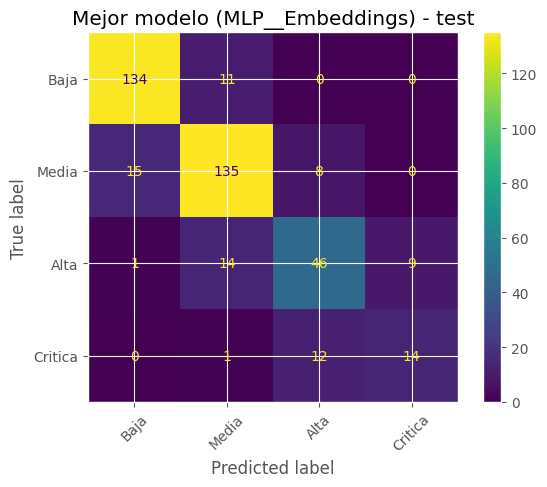

In [ ]:
# Recuperamos el run de refit del mejor modelo (su pipeline ya entrenada con train+val).
mejor_refit = runs[(runs["tags.stage"] == "refit_final") & (runs["tags.study_name"] == mejor["study_name"])].iloc[0]
mejor_modelo = mlflow.sklearn.load_model(f"runs:/{mejor_refit['run_id']}/model")

# Evaluación FINAL en test del modelo elegido.
pred_test = mejor_modelo.predict(X_test)
print("Macro recall (test):", round(recall_score(y_test, pred_test, average="macro"), 3))
print(classification_report(y_test, pred_test))
ConfusionMatrixDisplay.from_predictions(y_test, pred_test, labels=ORDEN_CLASES, xticks_rotation=45)
plt.title(f"Mejor modelo ({mejor['study_name']}) - test")
plt.show()

Guarda ahora el modelo para utilizarlo en la siguiente fase

In [ ]:
import cloudpickle

# El pipeline elegido contiene un tokenizador propio (y se cargó "por valor" desde MLflow),
# así que lo serializamos con cloudpickle para que el artefacto quede autocontenido y portable.
with open("modelo_final.pkl", "wb") as f:
    cloudpickle.dump(mejor_modelo, f)

with mlflow.start_run(run_name=f"modelo_final_{mejor['study_name']}"):
    mlflow.set_tag("stage", "modelo_final")
    mlflow.log_param("modelo_elegido", mejor["study_name"])
    mlflow.log_metric("macro_recall_test", float(recall_score(y_test, pred_test, average="macro")))
    # cloudpickle evita el serializador estricto (skops) que rechaza el tokenizador propio
    mlflow.sklearn.log_model(mejor_modelo, name="modelo_final", serialization_format="cloudpickle")
print("Modelo exportado a modelo_final.pkl")

NameError: name 'mejor_modelo' is not defined

Responde:

1. ¿Por qué el conjunto de **test** se lee recién al final y la selección se hace por `macro_recall_val`? **(0.2 pts)**
2. Además de la métrica, ¿qué otros criterios considerarías para elegir el modelo de **producción**? En particular: si el mejor modelo usa **embeddings**, ¿qué implica eso en inferencia (pista: hay que llamar a la API de `gemini-embedding-001`)? **(0.2 pts)**
3. Mira el desempeño **por clase** en test, especialmente `Critica`. ¿El modelo sirve para el objetivo de negocio (priorizar bien los tickets críticos)? **(0.2 pts)**
4. ¿Qué información registrarías en MLflow para que este modelo sea **reproducible y desplegable** por otra persona del equipo? **(0.2 pts)**
5. Mirando todo el barrido, ¿el mejor modelo justifica su complejidad frente a alternativas más simples? ¿Cuál llevarías tú a producción y por qué? **(0.2 pts)**

_Subtotal preguntas: 1.0 pts_

**Responde aquí**

**1.** El conjunto de test se reserva hasta el final para obtener una estimación
imparcial del desempeño del modelo sobre datos no utilizados durante el
desarrollo. Si se usara test para escoger modelos o ajustar hiperparámetros,
las decisiones terminarían adaptándose indirectamente a ese conjunto y la
métrica dejaría de representar correctamente la capacidad de generalización.

Por eso, todos los modelos se comparan mediante `macro_recall_val`, usando
validación. Esta métrica asigna la misma importancia a cada clase, por lo que
evita que el buen desempeño en las clases mayoritarias oculte un bajo recall
en clases minoritarias como `Critica`. Una vez elegido el modelo, test se usa
una sola vez para reportar su rendimiento final.

**2.** Además de la métrica, consideraría el tiempo de entrenamiento e inferencia,
la latencia, el consumo de memoria, la estabilidad, la interpretabilidad, la
facilidad de mantenimiento, la seguridad y el costo operacional.

Si el modelo usa embeddings, cada ticket nuevo debe enviarse a
`gemini-embedding-001` para generar nuevamente un vector de 1024 dimensiones,
utilizando exactamente el mismo formato de texto usado en entrenamiento. Esto
introduce latencia, costo por tokens, dependencia de una API externa, límites
de cuota y posibles fallas de disponibilidad. También se deben proteger las
credenciales y evaluar la privacidad del contenido enviado.

Además, debe mantenerse fija la versión del modelo de embeddings y monitorear
posibles cambios en su comportamiento, porque una modificación en los vectores
generados podría afectar las predicciones del clasificador.

**3.** El modelo obtuvo un macro recall de 0.739 en test y una accuracy de 0.82.
Sin embargo, para la clase `Critica` alcanzó un recall de 0.52: detectó
correctamente 14 de los 27 tickets críticos.

De los 13 tickets críticos no detectados, 12 fueron clasificados como `Alta`
y uno como `Media`; ninguno fue enviado a `Baja`. Esto reduce parcialmente
el riesgo, porque la mayoría de los errores todavía recibe una prioridad
elevada, pero el modelo no identifica como críticos a casi la mitad de los
casos.

Por lo tanto, el modelo es útil como herramienta de apoyo para priorización,
pero su desempeño en `Critica` todavía no parece suficiente para automatizar
completamente una decisión de negocio sensible. Conviene acompañarlo con
revisión humana o reglas adicionales de escalamiento para tickets con alta
probabilidad de pertenecer a las clases `Alta` o `Critica`.

**4.** Para asegurar reproducibilidad y despliegue registraría en MLflow:

- El nombre y versión del modelo, sus hiperparámetros y la semilla utilizada.
- La versión o hash de los datos y los índices exactos de train, validación y test.
- El commit de Git asociado al experimento.
- Las versiones de Python, scikit-learn, MLflow, Optuna y demás dependencias.
- El pipeline completo de preprocesamiento y clasificación.
- Los nombres, tipos y orden de las columnas de entrada.
- El modelo de embeddings (`gemini-embedding-001`), su dimensionalidad de
  1024 y el formato exacto usado para construir el texto.
- Macro recall de validación y test, métricas por clase, classification report
  y matriz de confusión.
- La firma del modelo, un ejemplo de entrada y los artefactos necesarios para
  cargarlo.
- El archivo serializado del modelo y las instrucciones para reproducir la
  inferencia.

También registraría etiquetas como responsable, fecha, etapa del modelo y
entorno de ejecución.

**5.** El mejor modelo según el criterio definido antes de experimentar fue el MLP
con embeddings, con un macro recall de validación de 0.797 y de test de
0.739. Superó claramente en validación a LightGBM + BoW, que obtuvo 0.740,
aunque la diferencia en test fue menor.

El MLP tiene mayor costo computacional y requiere generar embeddings mediante
`gemini-embedding-001` durante la inferencia. Sin embargo, para mantener la
consistencia con el protocolo experimental, llevaría a producción el MLP con
embeddings, ya que fue seleccionado sin utilizar el conjunto de test y es el
pipeline exportado y desplegado en la Parte 3.

En un escenario real también mantendría LightGBM + BoW como alternativa de
menor costo para comparar latencia, disponibilidad y desempeño en producción,
pero el modelo desplegado en este proyecto corresponde al MLP seleccionado por
macro recall de validación.